In [50]:
import pandas as pd
import numpy as np
from pycaret.classification import load_model, predict_model
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import joblib

# Innit


In [30]:
# Innit
data_24_25 = pd.read_csv('../../data/joint/24-25/merged_player_data.csv')

data_36 = data_24_25[data_24_25['event'] == 36]
data_37 = data_24_25[data_24_25['event'] == 37]
data_38 = data_24_25[data_24_25['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']

data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']

data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']


# Clean Sheets


In [ ]:
cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4',  'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5',  'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


In [96]:
# Load model
g_cs_model = load_model('../gk_cs_model')

Transformation Pipeline and Model Successfully Loaded


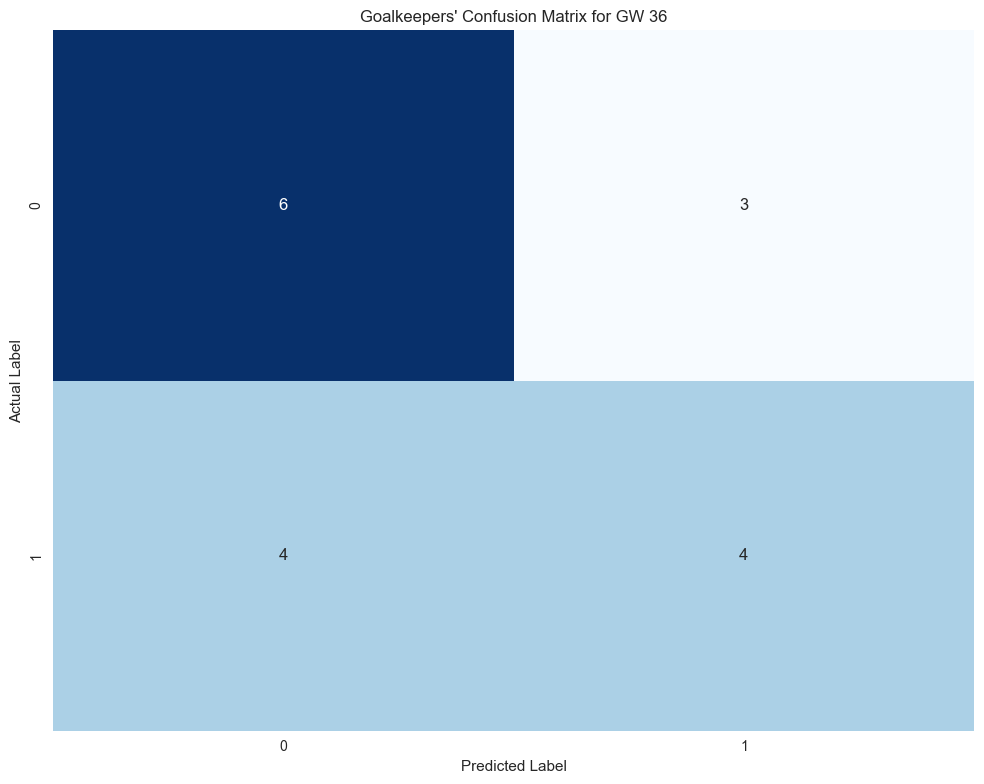

In [83]:
data_36_gk_cs = data_36_gk[cs_features]
cs = data_36_gk_cs[['clean_sheets']].copy()
data_36_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(g_cs_model, data=data_36_gk_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_gk
data_36_gk['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



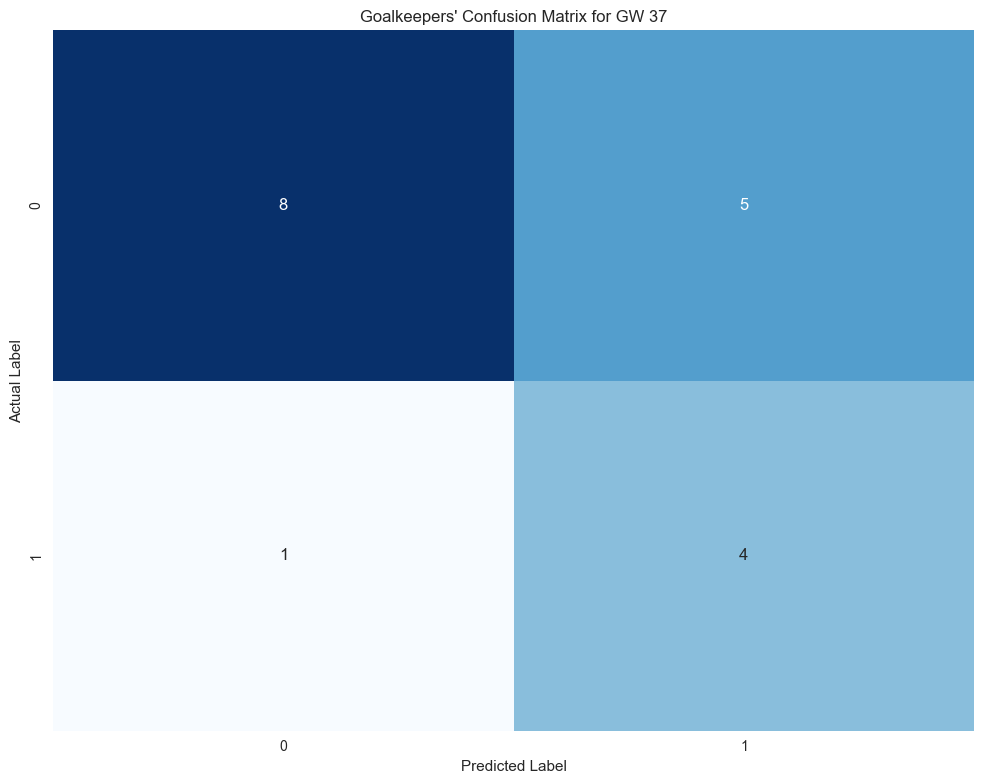

In [84]:
data_37_gk_cs = data_37_gk[cs_features]
cs = data_37_gk_cs[['clean_sheets']].copy()
data_37_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(g_cs_model, data=data_37_gk_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_gk
data_37_gk['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



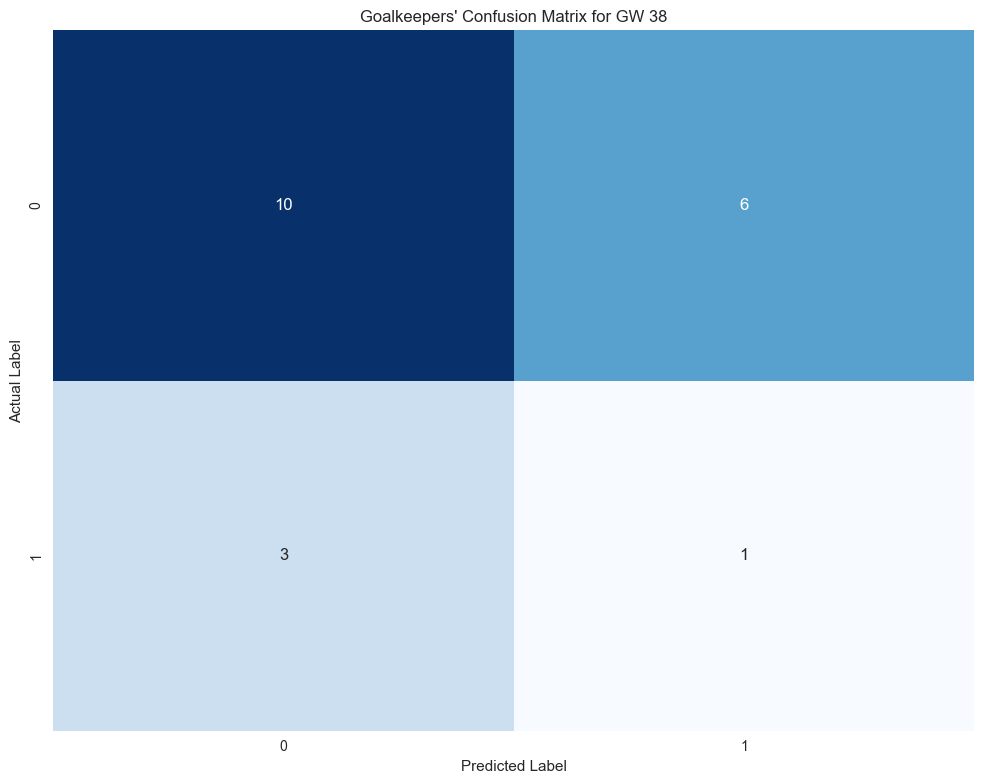

In [85]:
data_38_gk_cs = data_38_gk[cs_features]
cs = data_38_gk_cs[['clean_sheets']].copy()
data_38_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(g_cs_model, data=data_38_gk_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_gk
data_38_gk['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## DEF


In [97]:
# Load model
def_cs_model = load_model('../def_cs_model')

Transformation Pipeline and Model Successfully Loaded


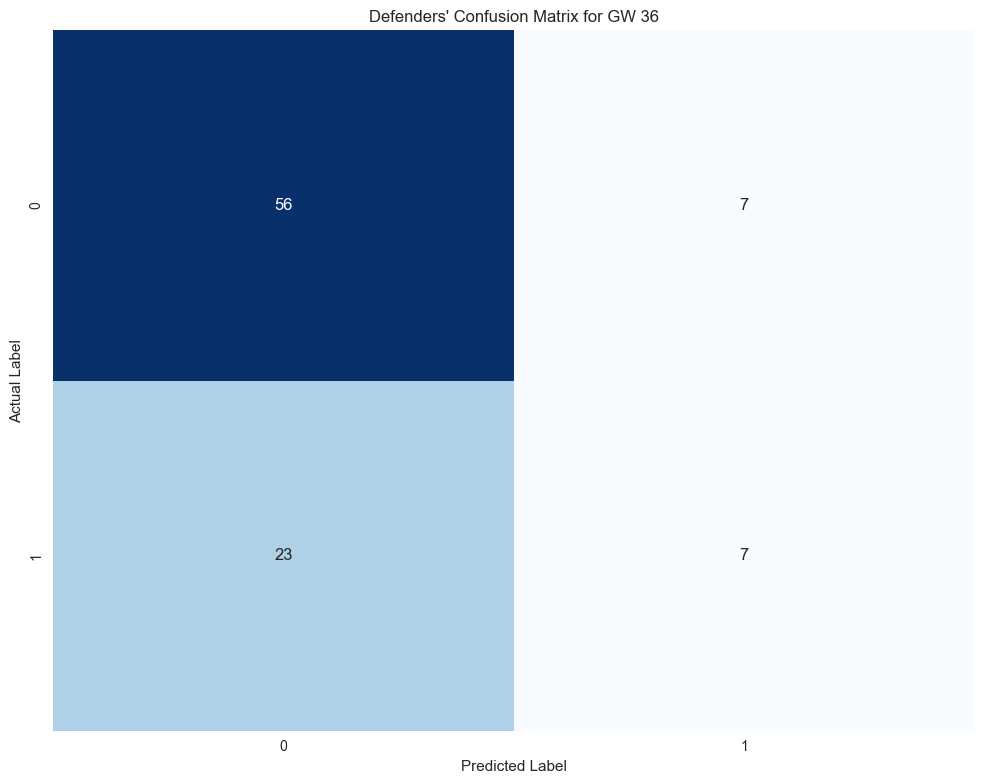

In [88]:
data_36_def_cs = data_36_def[cs_features]
cs = data_36_def_cs[['clean_sheets']].copy()
data_36_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(def_cs_model, data=data_36_def_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_def
data_36_def['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



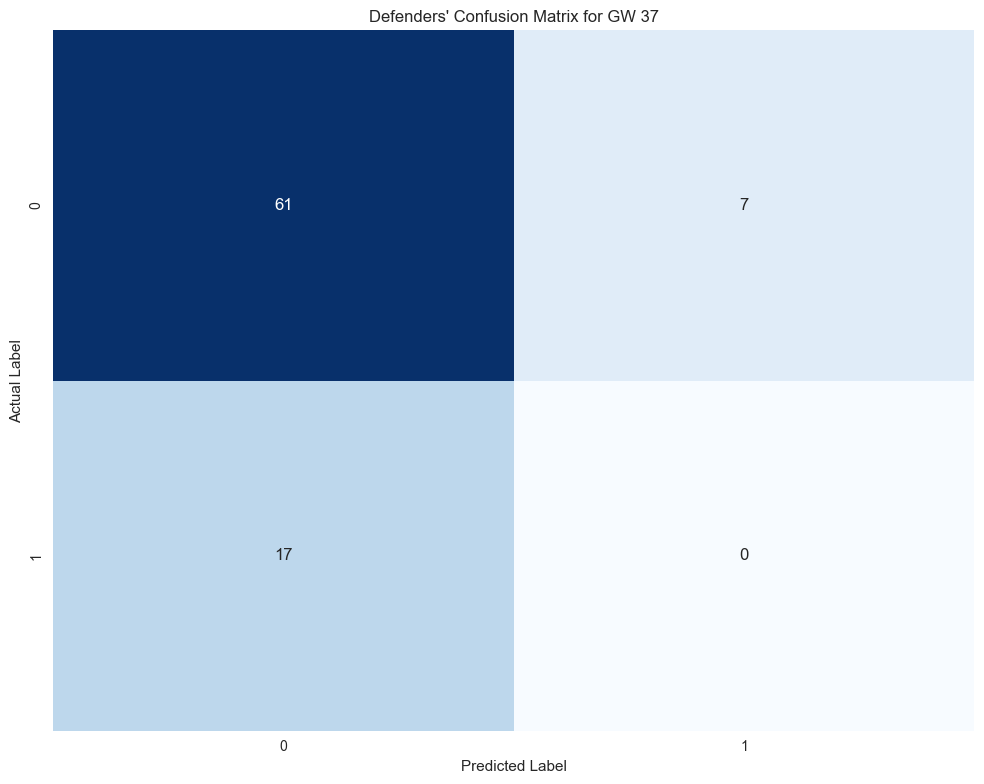

In [89]:
data_37_def_cs = data_37_def[cs_features]
cs = data_37_def_cs[['clean_sheets']].copy()
data_37_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(def_cs_model, data=data_37_def_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_def
data_37_def['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



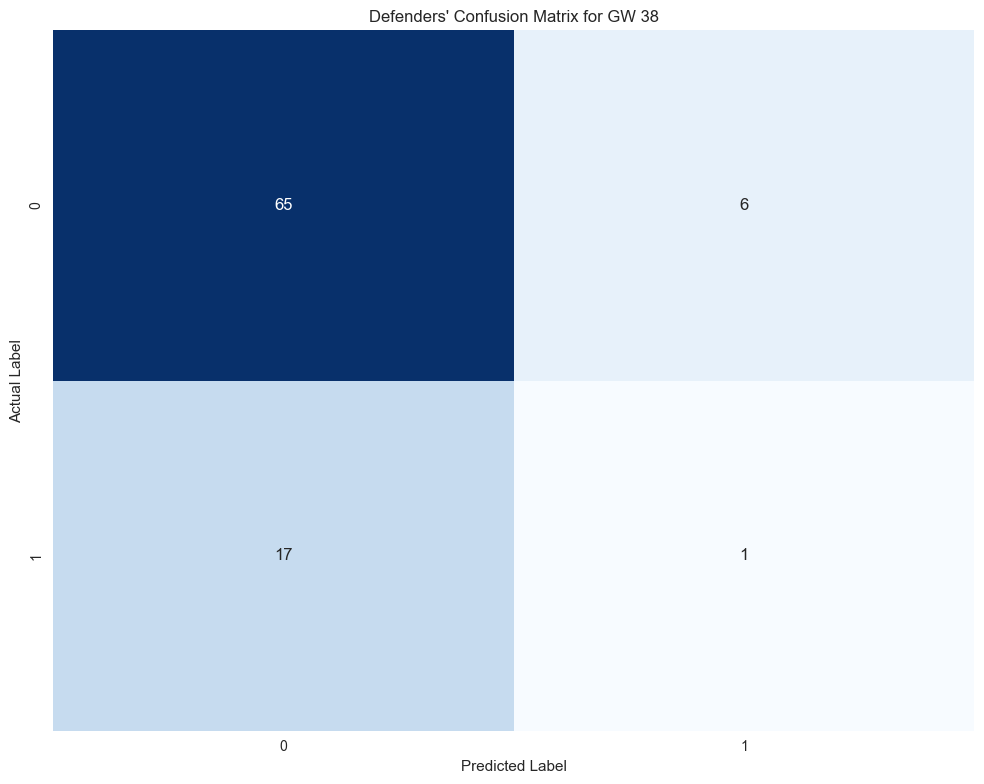

In [90]:
data_38_def_cs = data_38_def[cs_features]
cs = data_38_def_cs[['clean_sheets']].copy()
data_38_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(def_cs_model, data=data_38_def_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_def
data_38_def['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## MID


# Yellow Cards


In [ ]:
y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',

                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


In [ ]:
# Load model
g_cs_model = load_model('../gk_cs_model')

Transformation Pipeline and Model Successfully Loaded


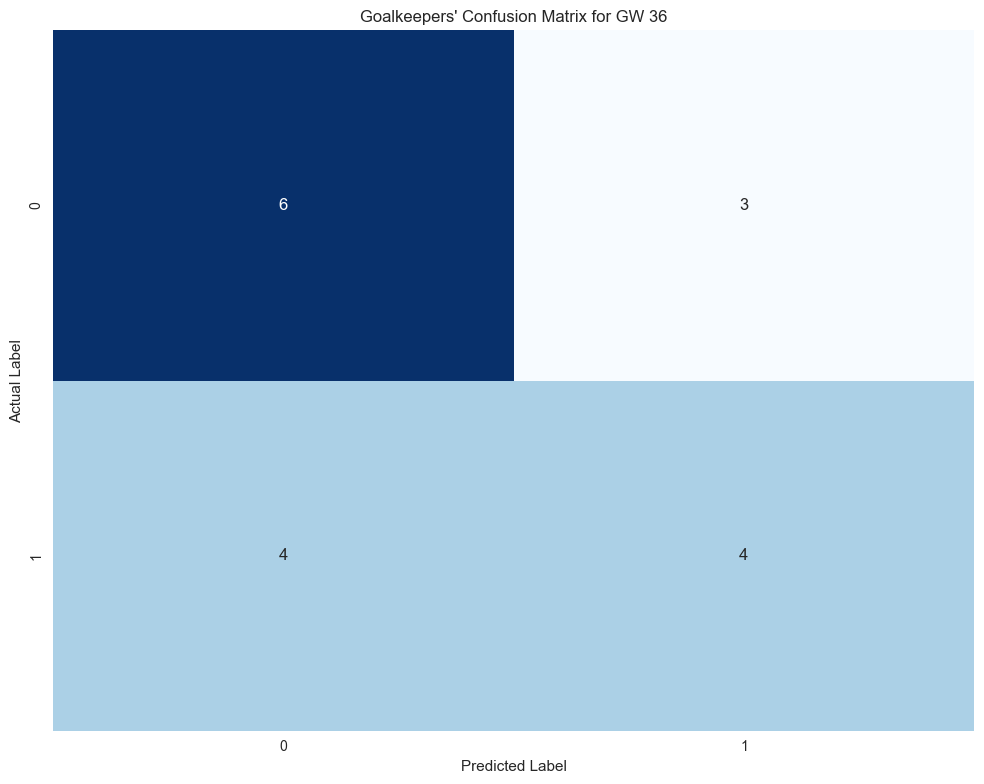

In [ ]:
data_36_gk_cs = data_36_gk[cs_features]
cs = data_36_gk_cs[['clean_sheets']].copy()
data_36_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(g_cs_model, data=data_36_gk_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_gk
data_36_gk['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



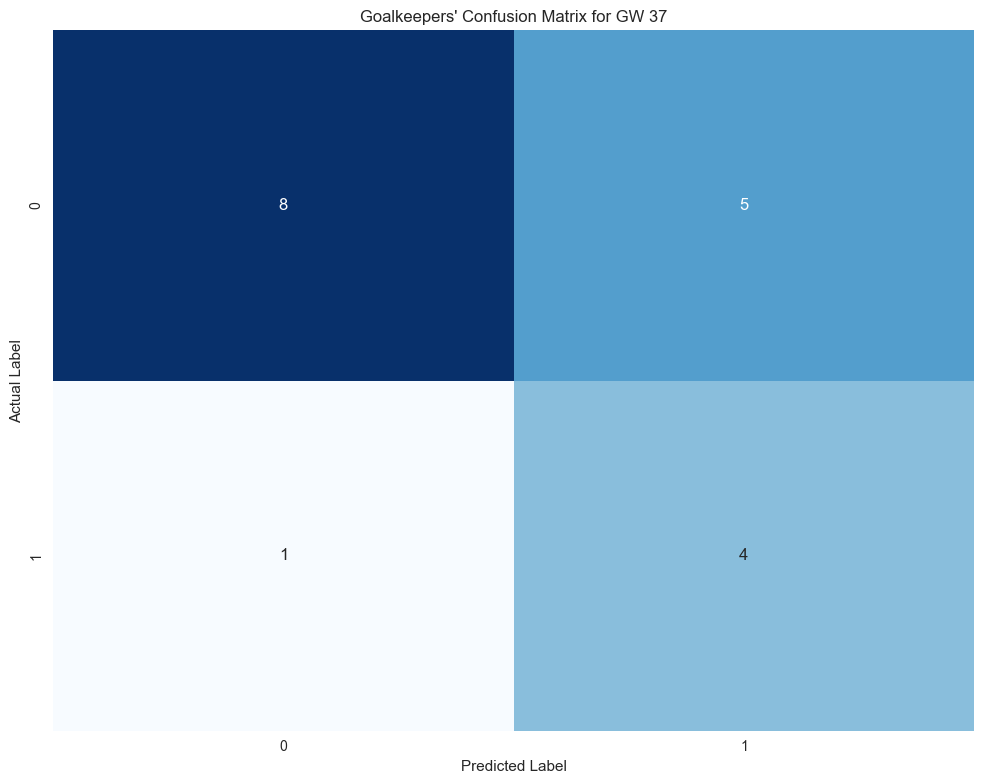

In [ ]:
data_37_gk_cs = data_37_gk[cs_features]
cs = data_37_gk_cs[['clean_sheets']].copy()
data_37_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(g_cs_model, data=data_37_gk_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_gk
data_37_gk['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



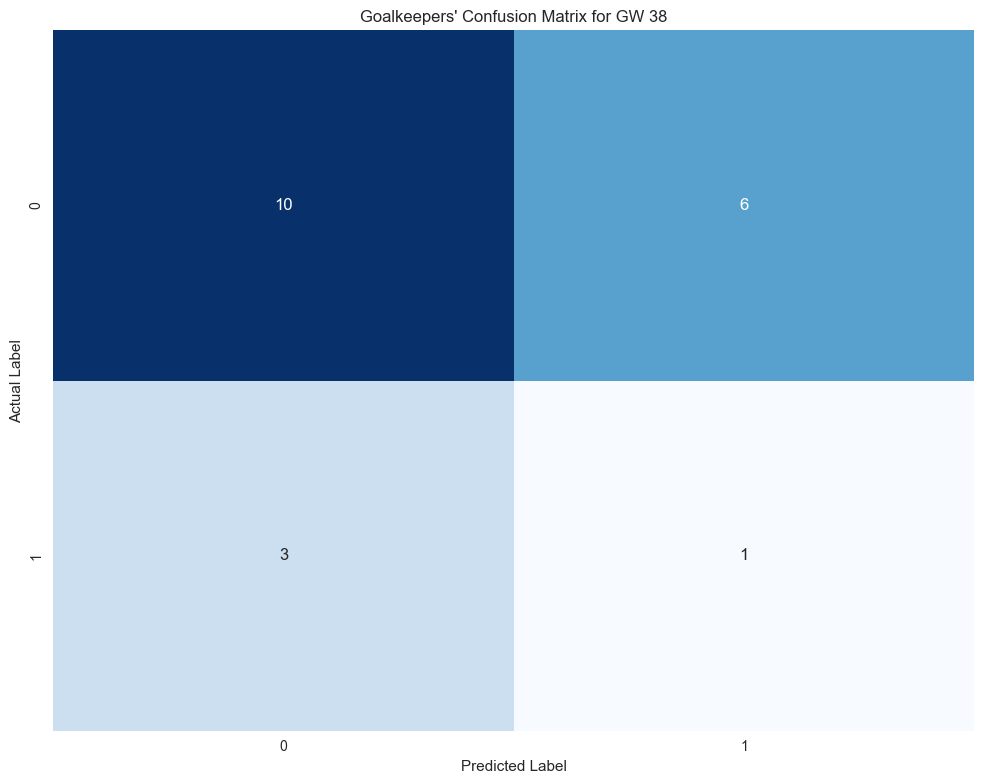

In [ ]:
data_38_gk_cs = data_38_gk[cs_features]
cs = data_38_gk_cs[['clean_sheets']].copy()
data_38_gk_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(g_cs_model, data=data_38_gk_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_gk
data_38_gk['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Goalkeepers\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## DEF


In [ ]:
# Load model
def_cs_model = load_model('../def_cs_model')

Transformation Pipeline and Model Successfully Loaded


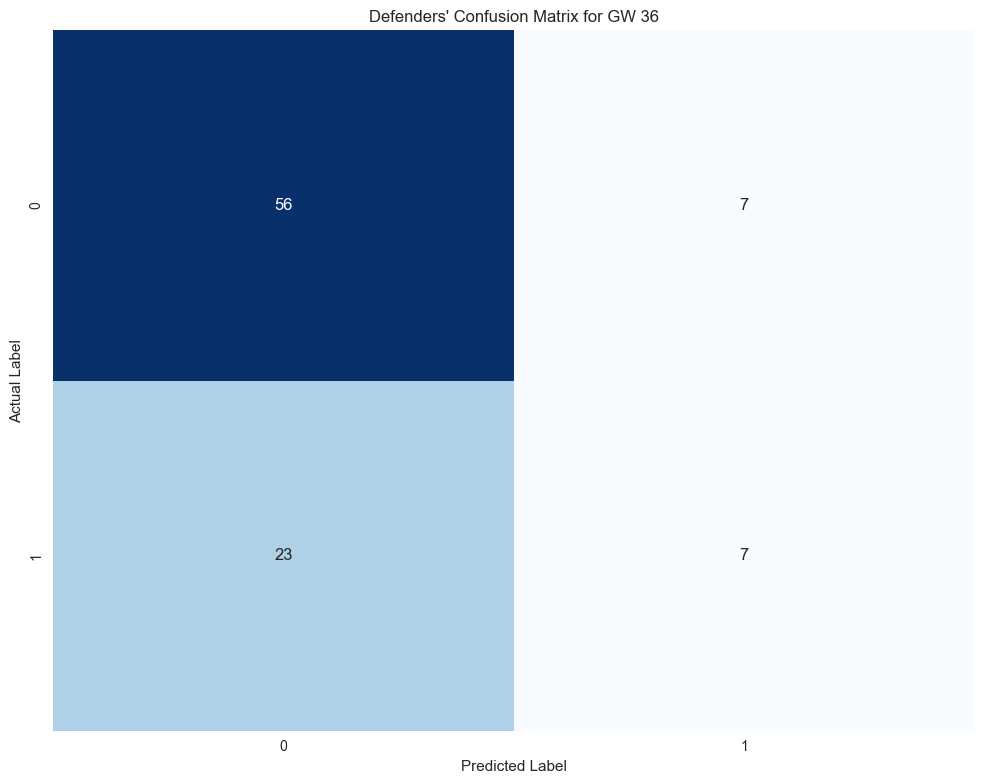

In [ ]:
data_36_def_cs = data_36_def[cs_features]
cs = data_36_def_cs[['clean_sheets']].copy()
data_36_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(def_cs_model, data=data_36_def_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_def
data_36_def['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



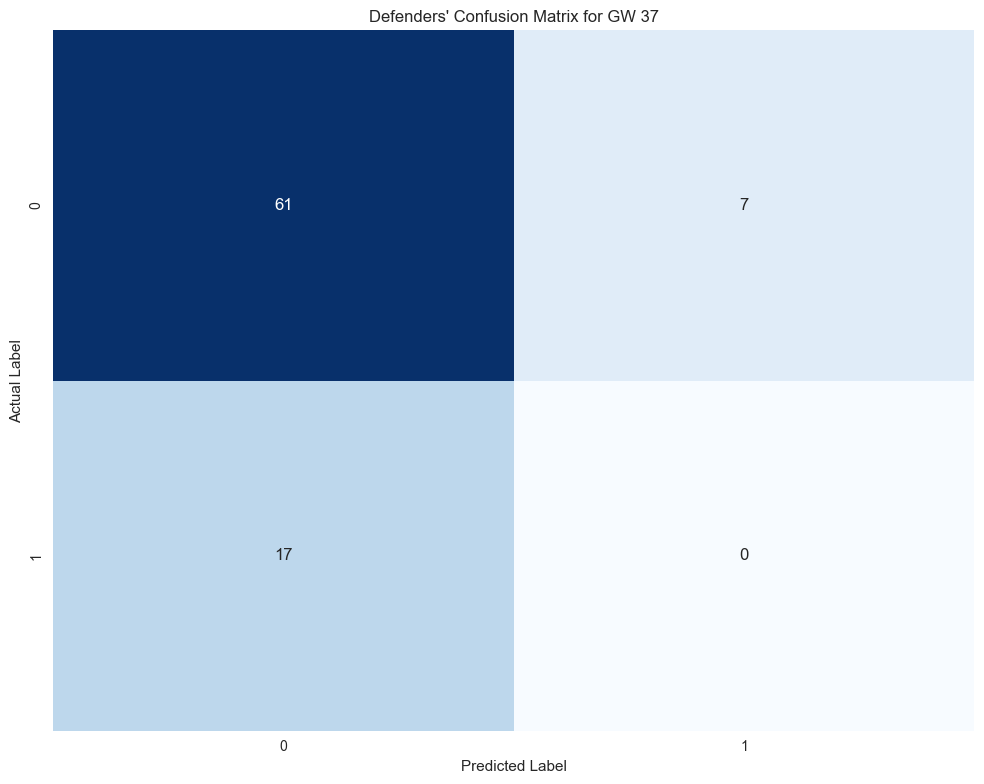

In [ ]:
data_37_def_cs = data_37_def[cs_features]
cs = data_37_def_cs[['clean_sheets']].copy()
data_37_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(def_cs_model, data=data_37_def_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_def
data_37_def['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



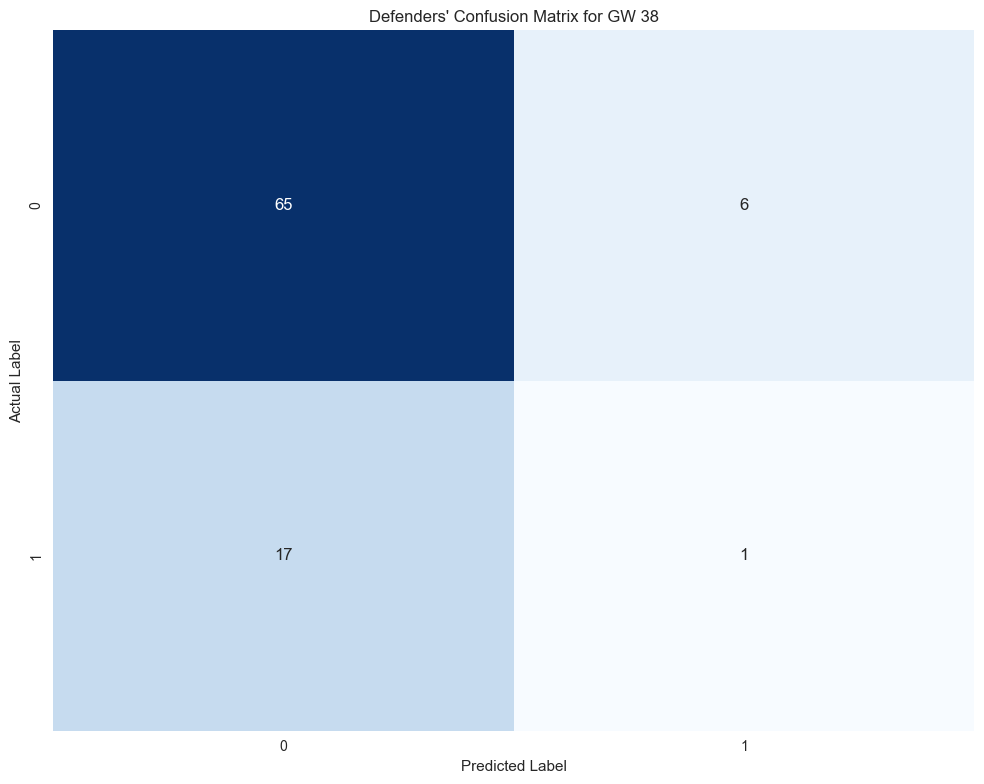

In [ ]:
data_38_def_cs = data_38_def[cs_features]
cs = data_38_def_cs[['clean_sheets']].copy()
data_38_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(def_cs_model, data=data_38_def_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_def
data_38_def['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Defenders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## MID


In [ ]:
# Load model
mid_cs_model = load_model('../mid_cs_model')

Transformation Pipeline and Model Successfully Loaded


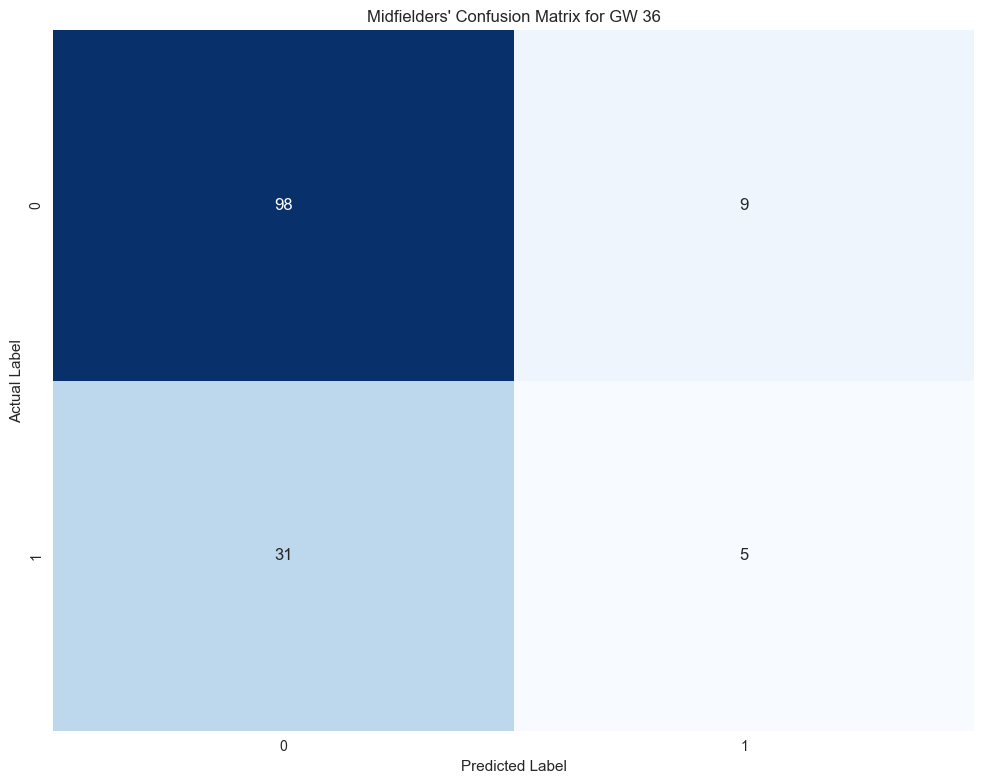

In [ ]:
data_36_mid_cs = data_36_mid[cs_features]
cs = data_36_mid_cs[['clean_sheets']].copy()
data_36_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(mid_cs_model, data=data_36_mid_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_mid
data_36_mid['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



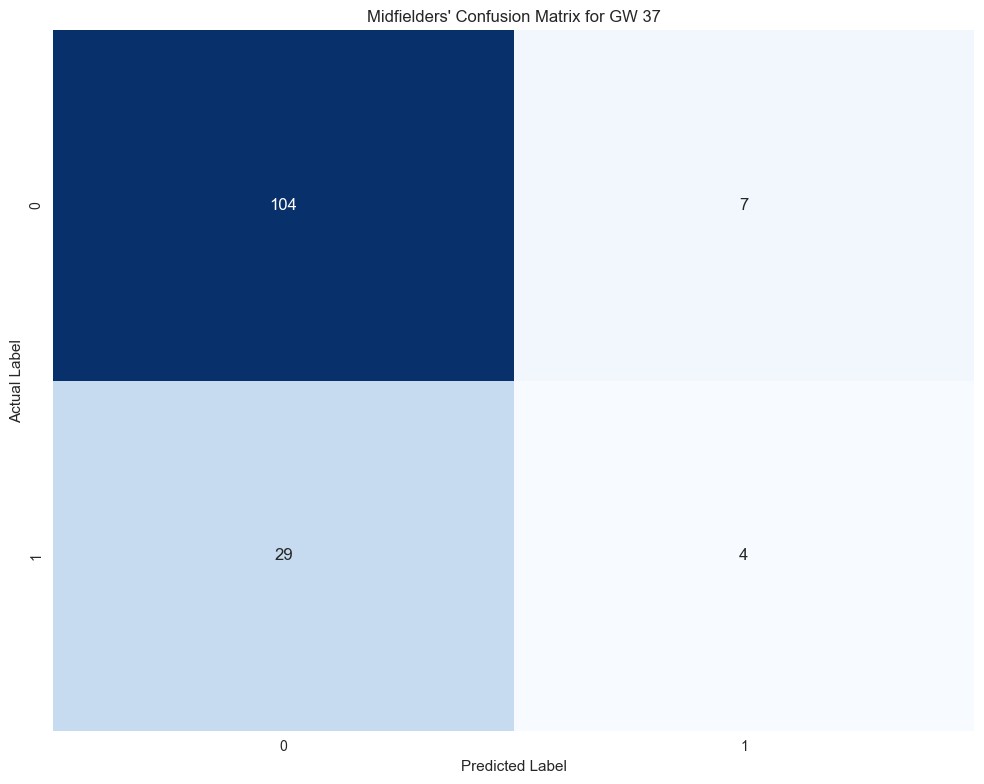

In [ ]:
data_37_mid_cs = data_37_mid[cs_features]
cs = data_37_mid_cs[['clean_sheets']].copy()
data_37_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(mid_cs_model, data=data_37_mid_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_mid
data_37_mid['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



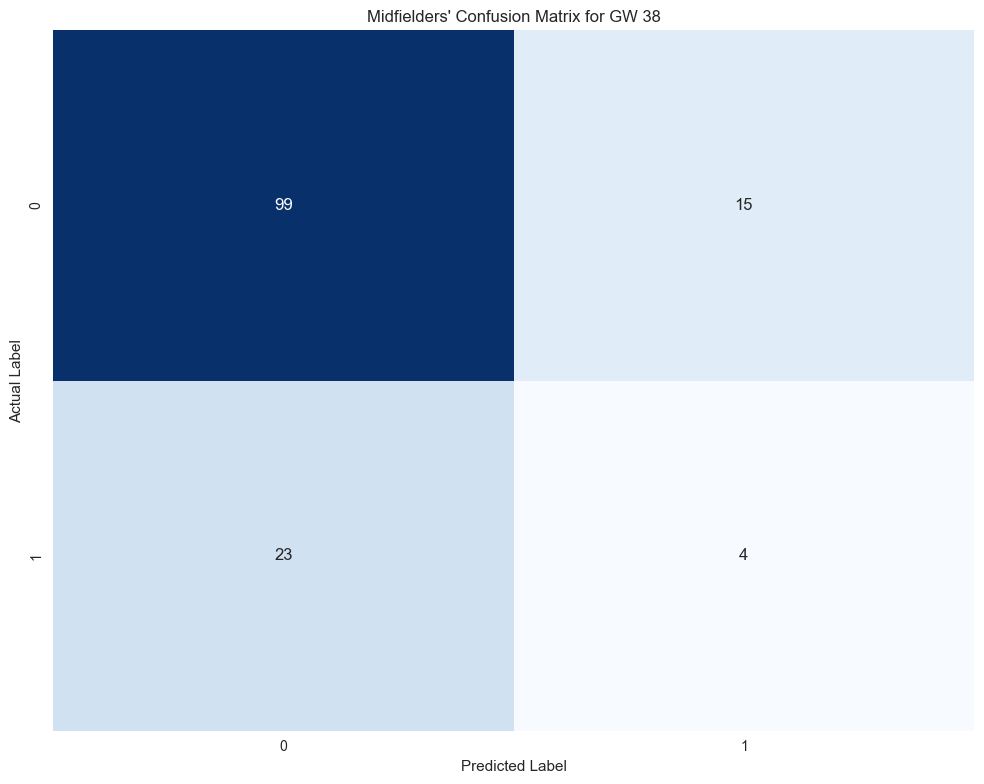

In [ ]:
data_38_mid_cs = data_38_mid[cs_features]
cs = data_38_mid_cs[['clean_sheets']].copy()
data_38_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(mid_cs_model, data=data_38_mid_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_mid
data_38_mid['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



In [92]:
# Load model
mid_cs_model = load_model('../mid_cs_model')

Transformation Pipeline and Model Successfully Loaded


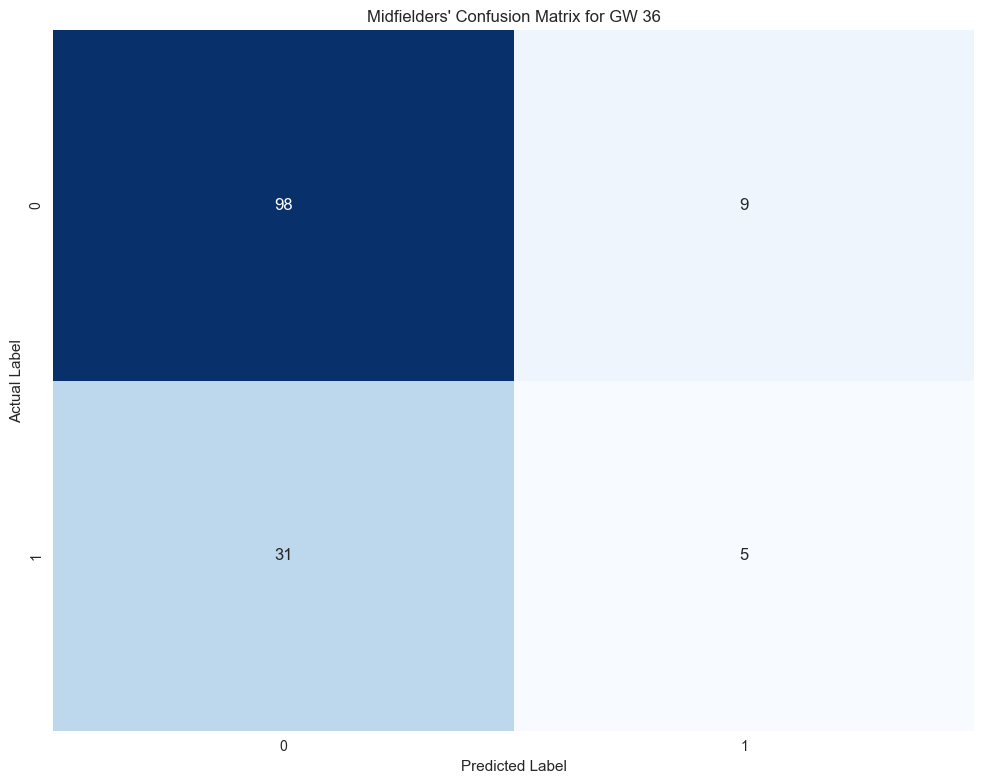

In [93]:
data_36_mid_cs = data_36_mid[cs_features]
cs = data_36_mid_cs[['clean_sheets']].copy()
data_36_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_36 = predict_model(mid_cs_model, data=data_36_mid_cs)
cs_preds_36 = cs_preds_36.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_36 to data_36_mid
data_36_mid['cs_preds'] = cs_preds_36[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_36[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 36')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



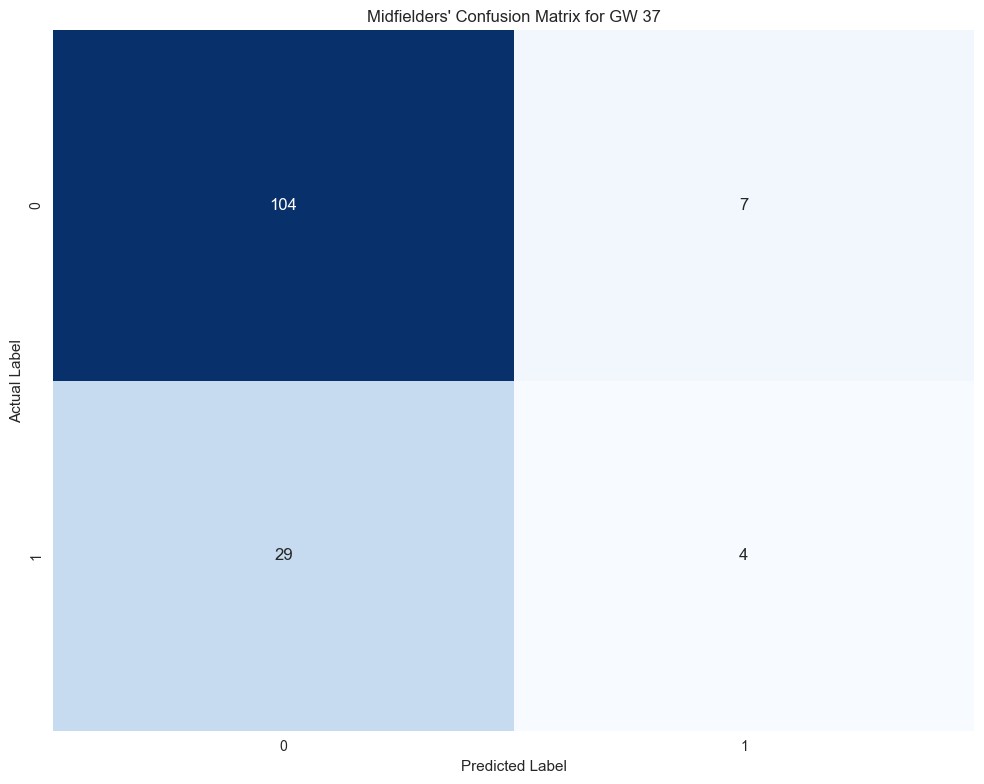

In [94]:
data_37_mid_cs = data_37_mid[cs_features]
cs = data_37_mid_cs[['clean_sheets']].copy()
data_37_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_37 = predict_model(mid_cs_model, data=data_37_mid_cs)
cs_preds_37 = cs_preds_37.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_37 to data_37_mid
data_37_mid['cs_preds'] = cs_preds_37[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_37[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 37')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()



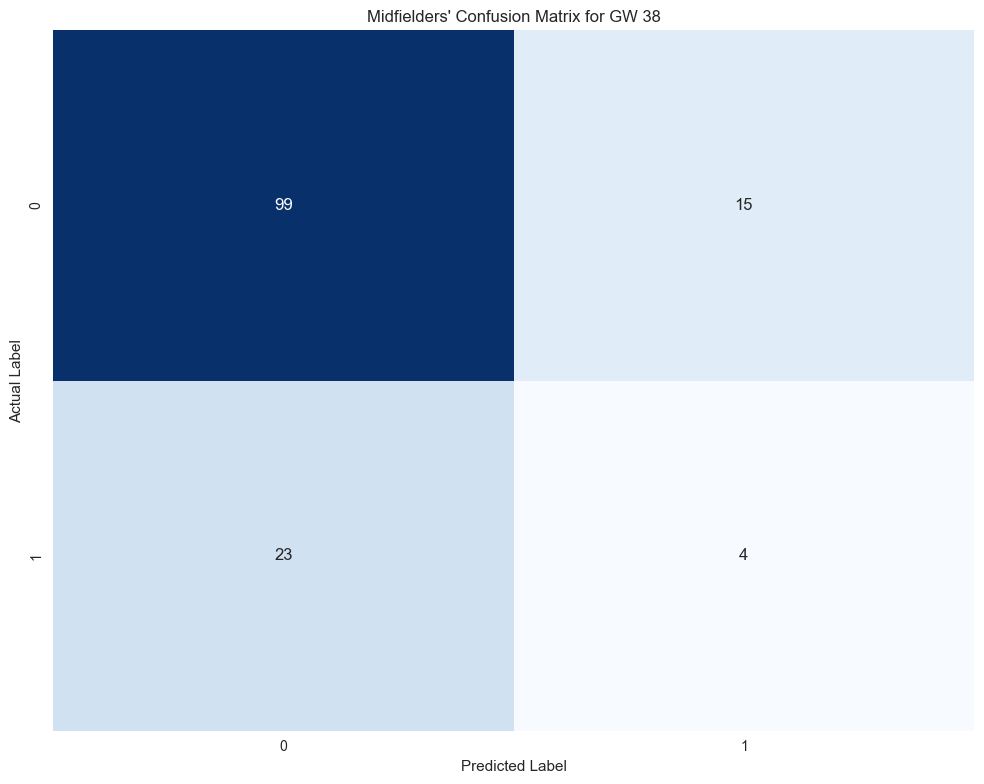

In [95]:
data_38_mid_cs = data_38_mid[cs_features]
cs = data_38_mid_cs[['clean_sheets']].copy()
data_38_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

cs_preds_38 = predict_model(mid_cs_model, data=data_38_mid_cs)
cs_preds_38 = cs_preds_38.rename(columns={'prediction_label': 'cs_preds_trans'})

# Add cs_preds_38 to data_38_mid
data_38_mid['cs_preds'] = cs_preds_38[['cs_preds_trans']]


actual = cs['clean_sheets'] # The actual classes
predicted = cs_preds_38[['cs_preds_trans']] # The predicted classes

cm = confusion_matrix(actual, predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Label the axes
plt.title('Midfielders\' Confusion Matrix for GW 38')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

